In [11]:
import gymnasium as gym
import numpy as np
import torch
from torch import nn
from dqn import Trainer
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t
import pygame
import os

GAMMA = 0.99
TRUNC_LENGTH = 2000

# Q2 a)

In [12]:
# creating the modified environment
TRUNC_LENGTH = 2000
env = gym.make('MountainCar-v0', max_episode_steps=TRUNC_LENGTH)

seeds = [44, 63, 11, 15, 90, 21, 0, 12, 52, 8, 42, 32, 31, 10, 98]

In [ ]:
for seed in seeds:
    dqn_trainer = Trainer(
        env=env,
        gamma=GAMMA,
        seed=int(seed),
        use_wandb=False,
        wandb_project="RL_PA2",
        wandb_run_name=f"q2_train_{seed}",
        trunc_length=TRUNC_LENGTH,
    )

    train_rewards = dqn_trainer.train(num_episodes=2000, logdir="q2logs")

Mean of last 10 episodes: -132.58
Variance (last 50 episodes): 23.69959
Episode when mean reward first reaches 90% of reward range: 246


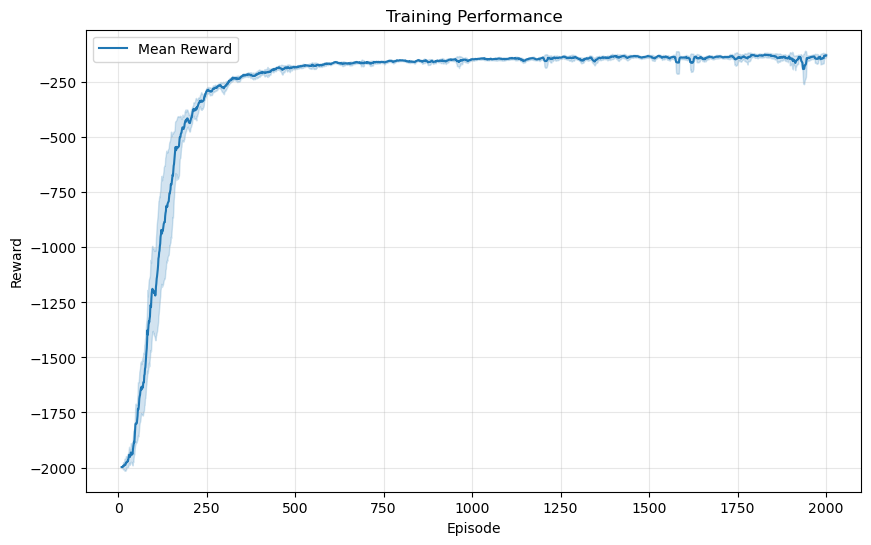

In [ ]:
def plot_mean_ci(
    seeds,
    logs_dir,
    reward_file,
    run_prefix="q2_train_",
    confidence=0.95,
    title="Performance Across Seeds",
    ylabel="Return",
    color="tab:blue",
    window_size=10,
    show=True,
    print_missing=True,
):
    all_rewards = []
    loaded_seeds = []

    for seed in seeds:
        rewards_path = os.path.join(logs_dir, f"{run_prefix}{seed}", reward_file)
        if os.path.exists(rewards_path):
            r = np.load(rewards_path)
            if len(r) >= window_size:
                r = np.convolve(r, np.ones(window_size) / window_size, mode="valid")
                all_rewards.append(r)
                loaded_seeds.append(seed)
        elif print_missing:
            print(f"Missing file for seed {seed}: {rewards_path}")

    if len(all_rewards) == 0:
        raise ValueError(f"No '{reward_file}' files found for the provided seeds.")
    
    max_len = max(len(r) for r in all_rewards)
    reward_matrix = np.full((len(all_rewards), max_len), np.nan, dtype=np.float32)
    for i, rewards in enumerate(all_rewards):
        reward_matrix[i, :len(rewards)] = rewards

    mean_rewards = np.nanmean(reward_matrix, axis=0)
    ci = np.zeros(max_len, dtype=np.float32)

    for ep in range(max_len):
        vals = reward_matrix[:, ep]
        vals = vals[~np.isnan(vals)]
        n = len(vals)
        if n > 1:
            se = sem(vals)
            t_crit = t.ppf((1 + confidence) / 2.0, df=n - 1)
            ci[ep] = se * t_crit

    episodes = np.arange(window_size, window_size + max_len)

    variance = np.nanvar(mean_rewards[-50:])

    print("Mean of last 10 episodes:", np.nanmean(mean_rewards[-10:]))
    print("Variance (last 50 episodes):", variance)

    max_mean_reward = np.nanmax(mean_rewards)
    min_mean_reward = np.nanmin(mean_rewards)
    threshold = min_mean_reward + 0.9 * (max_mean_reward - min_mean_reward)
    crossing_indices = np.where(mean_rewards >= threshold)[0]
    if len(crossing_indices) > 0:
        crossing_idx = crossing_indices[0]
        crossing_episode = int(episodes[crossing_idx])
        print(f"Episode when mean reward first reaches 90% of reward range: {crossing_episode}")
    else:
        print("Mean reward never reached 90% of reward range.")

    plt.figure(figsize=(10, 6))
    plt.plot(episodes, mean_rewards, color=color, label="Mean Reward")
    plt.fill_between(
        episodes,
        mean_rewards - ci,
        mean_rewards + ci,
        color=color,
        alpha=0.2,
    )
    plt.xlabel("Episode")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    if show:
        plt.show()

LOGS_DIR = "/Users/maheshgondi/Documents/IITM/6/RL/RL-Assignments/PA2/q2logs"

# Train rewards plot
plot_mean_ci(
    seeds=seeds,
    logs_dir=LOGS_DIR,
    reward_file="train_rewards.npy",
    title="Training Performance",
    ylabel="Reward",
    color="tab:blue",
)

The optimal performance is acheived when the car is first accelerated backwards, and then can climb the hill to reach the goal state in one go. This results in a reward of > -100. There are some cases where the car directly tries to climb the hill without going backwards, and fails. These result in a lower reward of < -100. In some cases even though the car starts by going backwards, it does not go high enough to then reach the goal. It then ends up going back and forth twice resulting in an even worse performance. This is rare, and happens only for a few seeds.

# Q2 b)

In [ ]:
# visualizing the agent
for seed in seeds:
    env = gym.make('MountainCar-v0', render_mode='human')  
    dqn_trainer = Trainer(
            env=env,
            gamma=GAMMA,
            seed=int(seed),
            use_wandb=True,
            wandb_project="RL_PA2",
            wandb_run_name=f"q2_train_{seed}",
            trunc_length=TRUNC_LENGTH
        )

    test_rewards = dqn_trainer.test(env, weights_path=f"/Users/maheshgondi/Documents/IITM/6/RL/RL-Assignments/PA2/q2logs/q2_train_{seed}/policy_net.pt", logs_dir="q2logs", num_episodes=3, save_results=True, render=True)
    env.close()

# Q3 a)

In [ ]:
trunc_lengths= [200, 1000]
for trunc_length in trunc_lengths:
    env = gym.make('MountainCar-v0', max_episode_steps=trunc_length)
    for seed in seeds:
        dqn_trainer = Trainer(
            env=env,
            gamma=GAMMA,
            seed=int(seed),
            use_wandb=False,
            wandb_project="RL_PA2",
            wandb_run_name=f"q3_trunc_{trunc_length}_seed_{seed}",
            trunc_length=trunc_length
        )
        
        train_rewards = dqn_trainer.train(num_episodes=2000, logdir="q3logs")

Mean of last 10 episodes: -125.509995
Variance (last 50 episodes): 3.8426456
Episode when mean reward first reaches 90% of reward range: 1591


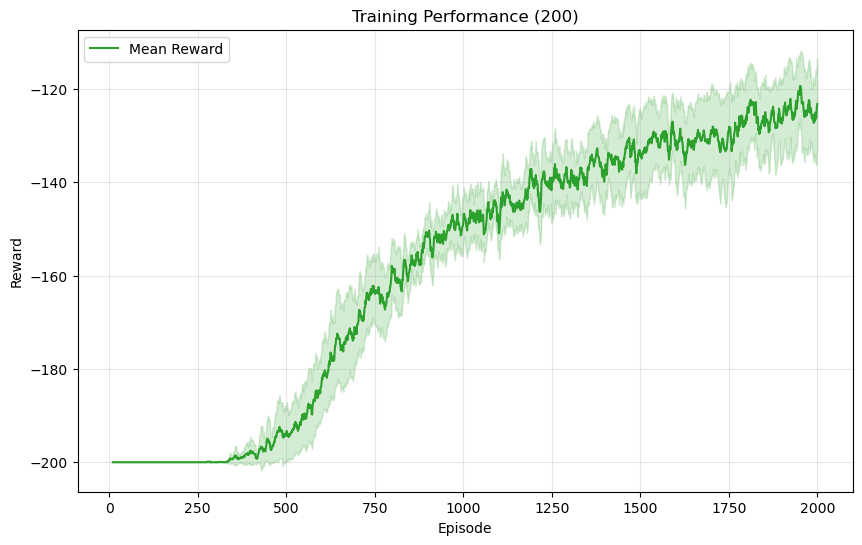

Mean of last 10 episodes: -133.15334
Variance (last 50 episodes): 112.094124
Episode when mean reward first reaches 90% of reward range: 407


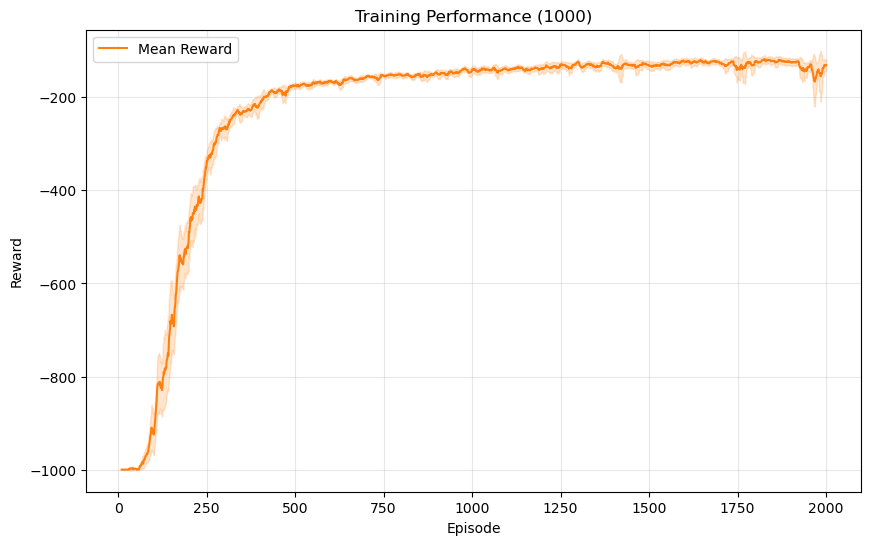

In [ ]:
LOGS_DIR = "/Users/maheshgondi/Documents/IITM/6/RL/RL-Assignments/PA2/q3logs"

plot_mean_ci(
    seeds=seeds,
    logs_dir=LOGS_DIR,
    run_prefix="q3_trunc_200_seed_",
    reward_file="train_rewards_64.npy",
    title="Training Performance (200)",
    ylabel="Reward",
    color="tab:green",
)

plot_mean_ci(
    seeds=seeds,
    logs_dir=LOGS_DIR,
    run_prefix="q3_trunc_1000_seed_",
    reward_file="train_rewards_64.npy",
    title="Training Performance (1000)",
    ylabel="Reward",
    color="tab:orange",
)

# Q4 d) Part i)

In [ ]:
rho = [1, 4]

for r in rho:
    env = gym.make('MountainCar-v0', max_episode_steps=TRUNC_LENGTH)
    for batch_size in [16, 32, 64, 128, 256]:
        for seed in seeds:
            dqn_trainer = Trainer(
                env=env,
                gamma=GAMMA,
                seed=int(seed),
                use_wandb=False,
                wandb_project="RL_PA2",
                wandb_run_name=f"q4_rho_{r}_seed_{seed}",
                trunc_length=TRUNC_LENGTH,
                batch_size=batch_size
            )
            print(f"Training with rho={r}, batch_size={batch_size}, seed={seed}")
            train_rewards = dqn_trainer.train(num_episodes=1500, logdir="q4logs", replay_factor=r)

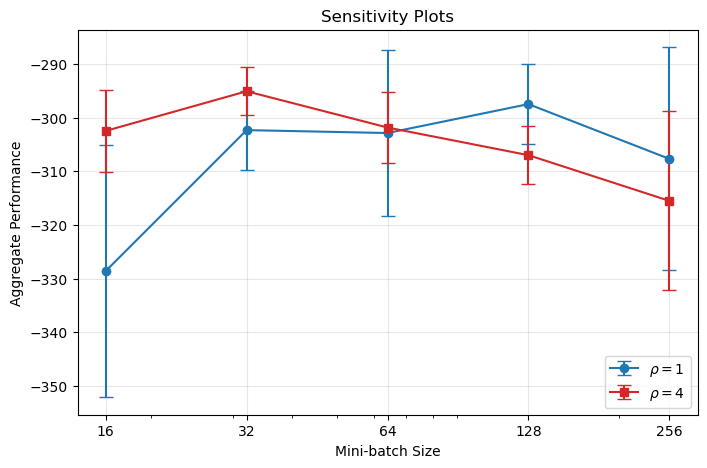

In [22]:
def plot_sensitivity(
    seeds,
    logs_dir,
    batch_sizes,
    rhos=[1, 4],
    confidence=0.95,
    window_size=10,
    title="Sensitivity Plots",
    ylabel="Aggregate Performance",
):
    results = {rho: {"means": [], "cis": []} for rho in rhos}

    for rho in rhos:
        for batch_size in batch_sizes:
            aggregate_scores = []

            for seed in seeds:
                path = os.path.join(
                    logs_dir,
                    f"q4_rho_{rho}_seed_{seed}",
                    f"train_rewards_{batch_size}.npy",
                )

                if not os.path.exists(path):
                    continue

                r = np.load(path)
                if len(r) < window_size:
                    continue

                # Smooth each run before computing the aggregate metric.
                r = np.convolve(r, np.ones(window_size) / window_size, mode="valid")
                n = len(r)

                if n == 0:
                    continue
                if n == 1:
                    scaled_auc = float(r[0])
                else:
                    x = np.arange(n, dtype=np.float32)
                    auc = np.trapezoid(r, x)
                    scaled_auc = float(auc / n)

                aggregate_scores.append(scaled_auc)

            if len(aggregate_scores) == 0:
                results[rho]["means"].append(np.nan)
                results[rho]["cis"].append(0.0)
                continue

            aggregate_scores = np.asarray(aggregate_scores, dtype=np.float32)
            mean_score = float(np.mean(aggregate_scores))

            if len(aggregate_scores) > 1:
                se = sem(aggregate_scores)
                t_crit = t.ppf((1 + confidence) / 2.0, df=len(aggregate_scores) - 1)
                ci = float(se * t_crit)
            else:
                ci = 0.0

            results[rho]["means"].append(mean_score)
            results[rho]["cis"].append(ci)

    plt.figure(figsize=(8, 5))

    for rho, marker, color in zip(rhos, ["o", "s"], ["tab:blue", "tab:red"]):
        means = results[rho]["means"]
        cis = results[rho]["cis"]

        plt.errorbar(
            batch_sizes,
            means,
            yerr=cis,
            marker=marker,
            capsize=5,
            label=f"$\\rho = {rho}$",
            color=color,
        )

    plt.xscale("log")
    plt.xlabel("Mini-batch Size")
    plt.xticks(batch_sizes, [str(bs) for bs in batch_sizes])
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_sensitivity(
    seeds=seeds,
    logs_dir="q4logs",
    batch_sizes=[16, 32, 64, 128, 256],
    rhos=[1, 4]
)